In [1]:
# Pandas is used to load and handle the dataset (tables, columns, rows)
import pandas as pd

# Used to split the dataset into training and testing parts
from sklearn.model_selection import train_test_split

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score


In [2]:
# First, install the missing dependency
!pip install xlrd>=2.0.1

# Then import pandas if not already imported
import pandas as pd

# Now read the Excel file
df = pd.read_excel('.\default of credit card clients.xls', header=1, index_col=0)

# Note: If you're still having path issues, try using raw strings or forward slashes:
# df = pd.read_excel(r'.\default of credit card clients.xls', header=1, index_col=0)
# or
# df = pd.read_excel('./default of credit card clients.xls', header=1, index_col=0)

In [3]:
df.rename(columns={"default payment next month": "target"}, inplace=True)

print(df["target"].value_counts())

target
0    23364
1     6636
Name: count, dtype: int64


In [4]:
# All columns except the target are input features
input_features = list(df.columns[:-1])  # target is the last column

# The target column indicates default (1) or no default (0)


In [5]:
# Percentage of data used for testing
PERCENTAGE_SAMPLES_USED_FOR_TESTING = 0.3

# Split the dataset into train and test sets
# stratify ensures the ratio of defaulters/non-defaulters stays the same
train, test = train_test_split(
    df,
    test_size=PERCENTAGE_SAMPLES_USED_FOR_TESTING,
    random_state=42,
    stratify=df["target"]
)

print(
    "Training samples:", len(train),
    "| Testing samples:", len(test)
)


Training samples: 21000 | Testing samples: 9000


In [6]:
# List of classifier types we want to use
classifiers = [
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
]

# Create one model instance for each classifier
models = [classifier() for classifier in classifiers]


In [7]:
# Train each model using the training data
for m in models:
    m.fit(train[input_features], train["target"])

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
# Balanced accuracy considers performance on both classes equally
for m in models:
    predictions = m.predict(test[input_features])
    print("\nBalanced Accuracy for", str(m))
    print(balanced_accuracy_score(test["target"], predictions))



Balanced Accuracy for LogisticRegression()
0.5002511300853842

Balanced Accuracy for DecisionTreeClassifier()
0.6027642654178071

Balanced Accuracy for RandomForestClassifier()
0.6509177158247927


In [9]:
# Confusion matrices show correct and incorrect predictions per class
for m in models:
    predictions = m.predict(test[input_features])
    cm = confusion_matrix(test["target"], predictions, labels=m.classes_)
    print("\nConfusion matrix for", str(m))
    print(cm)



Confusion matrix for LogisticRegression()
[[7009    0]
 [1990    1]]

Confusion matrix for DecisionTreeClassifier()
[[5672 1337]
 [1202  789]]

Confusion matrix for RandomForestClassifier()
[[6604  405]
 [1275  716]]



Confusion Matrix for LogisticRegression()

Confusion Matrix for DecisionTreeClassifier()

Confusion Matrix for RandomForestClassifier()


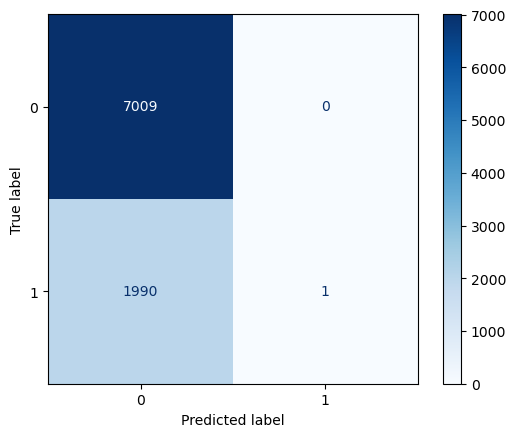

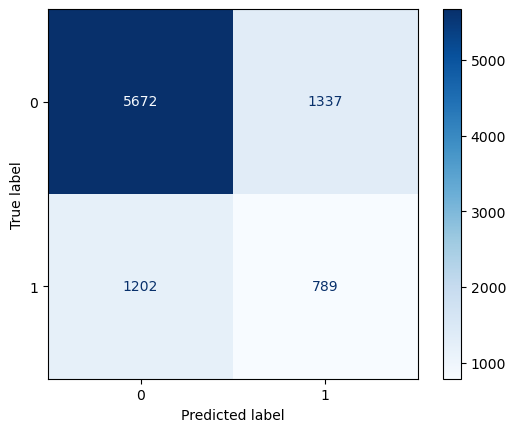

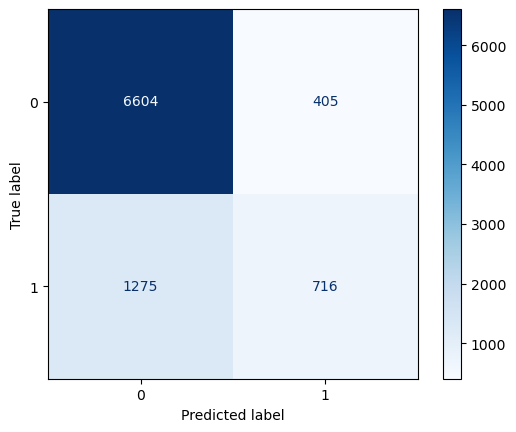

In [10]:
for m in models:
    print("\nConfusion Matrix for", str(m))
    ConfusionMatrixDisplay.from_estimator(
        m,
        X=test[input_features],
        y=test["target"],
        labels=m.classes_,
        cmap="Blues"
    )

In [11]:
# Detailed performance metrics for each class
for m in models:
    predictions = m.predict(test[input_features])
    print("\nClassification report for", str(m))
    print(classification_report(test["target"], predictions))


Classification report for LogisticRegression()
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7009
           1       1.00      0.00      0.00      1991

    accuracy                           0.78      9000
   macro avg       0.89      0.50      0.44      9000
weighted avg       0.83      0.78      0.68      9000


Classification report for DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      7009
           1       0.37      0.40      0.38      1991

    accuracy                           0.72      9000
   macro avg       0.60      0.60      0.60      9000
weighted avg       0.72      0.72      0.72      9000


Classification report for RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      7009
           1       0.64      0.36      0.46      1991

    accuracy                  

In [12]:
# ROC-AUC evaluates how well the model distinguishes defaulters from non-defaulters
for m in models:
    # Probability of class 1 (default)
    probabilities = m.predict_proba(test[input_features])[:, 1]

    print("\nROC-AUC for", str(m))
    print(roc_auc_score(test["target"], probabilities))


ROC-AUC for LogisticRegression()
0.6464537343427076

ROC-AUC for DecisionTreeClassifier()
0.6034430583223019

ROC-AUC for RandomForestClassifier()
0.7573144638102164
